(wavetank1_obstacles)=
# Wavetank1 with Obstacles

Passive advection in a given velocity field obtained by reading fgout data from a wave tank model.

Running this requires `shapely` and `clawpack`, the latter for the `animation_tools` that are further illustrated in this [demo notebook](https://www.clawpack.org/gallery/_static/apps/notebooks/visclaw/animation_tools_demo.html).


In [27]:
%matplotlib inline

In [28]:
from pylab import *
from importlib import reload
import shapely
from shapely import plotting as shapely_plotting
from clawpack.visclaw import animation_tools
from IPython.display import display, HTML
from clawpack.geoclaw import fgout_tools
from scipy.interpolate import RegularGridInterpolator


In [29]:
import sys
sys.path.insert(0,'../../src')

In [30]:
from geoclaw_debris import debris_tracking
reload(debris_tracking) # for debugging

<module 'geoclaw_debris.debris_tracking' from '/Users/zhora/Documents/geoclaw_debris/examples/wavetank1/../../src/geoclaw_debris/debris_tracking.py'>

## Load fgout data

This assumes that the individual fgout files (at a sequence of times) from running GeoClaw have already been combined into a single netCDF file so that we can just read in this one file and extract all the arrays.  The script `combine_fgout_nc.py` in this directory can be used for this purpose, if you run GeoClaw first.

To run this notebook without first running GeoClaw, you can download the sample netCDF file from
<http://depts.washington.edu/clawpack/geoclaw/geoclaw_debris/data/wavetank1_fgout_frames.nc>.

In [31]:
fname_nc='wavetank1_fgout_frames.nc'

x,y,t,qoi_arrays = fgout_tools.read_netcdf_arrays(fname_nc, qois=['h','u','v','B'], verbose=True)
# grid spacing
dx = x[1]-x[0]
dy = y[1]-y[0]


Reading data to fgout frames from nc file wavetank1_fgout_frames.nc
        nc file description:  
History:   Created Sat May  2 14:34:41 2026 in /Users/rjl/git/geoclaw_debris/wavetank1;  
    Loaded lon with shape (200,)
    Loaded lat with shape (60,)
    Loaded time with shape (101,)
    Loaded h with shape (101, 200, 60)
    Loaded u with shape (101, 200, 60)
    Loaded v with shape (101, 200, 60)
    Loaded B with shape (101, 200, 60)


## extract arrays and rearrange so indices correspond to (x,y,t):

In [32]:
X,Y = meshgrid(x, y, indexing='ij')

depth = qoi_arrays['h'].transpose((1,2,0))
u = qoi_arrays['u'].transpose((1,2,0))
v = qoi_arrays['v'].transpose((1,2,0))
B = qoi_arrays['B'].transpose((1,2,0))
B_xy = B[:,:,0]
mask = B_xy > 0 # extracting obstacle part for later (the +1 depth part)

In [33]:
print(f'len(x)={len(x)}, len(y)={len(y)}, len(t)={len(t)}')
print(f'shape of X,Y is {X.shape}')
print(f'shape of depth,u,v,B is {depth.shape}')

len(x)=200, len(y)=60, len(t)=101
shape of X,Y is (200, 60)
shape of depth,u,v,B is (200, 60, 101)


## Make interpolating functions that can be evaluated anywhere

In [34]:
method = 'linear'
fill_value = nan  # set value to nan if outside fgout grid extent
bounds_error = False  # don't throw an exception if outside

def make_fcn(qoi):
    """
    Create a function based on interpolating the fgout quantity of interest (qoi array)
    so that the function can be called with any x,y,t in the extent of the fgout grid
    """
    fcn1 = RegularGridInterpolator((x,y,t), qoi, method=method, fill_value=fill_value,
                                    bounds_error=bounds_error)
    # fcn1 must be called with one argument, a tuple (x,y,t)
    # turn this into a function that can be called with 3 arguments x,y,t:
    def fcn2(x,y,t):
        return fcn1((x,y,t))
    return fcn2
    
depth_fcn = make_fcn(depth)
u_fcn = make_fcn(u)
v_fcn = make_fcn(v)
B_fcn = make_fcn(B)


### Function for depth that's masked where there's no water

In [35]:
def depth_positive_fcn(x,y,t):
    h = depth_fcn(x,y,t)
    hpositive = ma.masked_where(h<0.001, h)
    return hpositive

### Plot topo and flow depth at one time

This topography is flat with elevation -1 m everywhere in the domain except where there is an obstacle with elevation +1 m.  The initial water elevation is 1 for $x<-3$ and 0 for $x > -3$. The jump discontinuity in depth (from 2  m to 1 m depth) at $x = -3$ leads to flow from left to right.

Change `k` in the cell below to view a different time, or see the animation later in the notebook to see how the flow evolves.

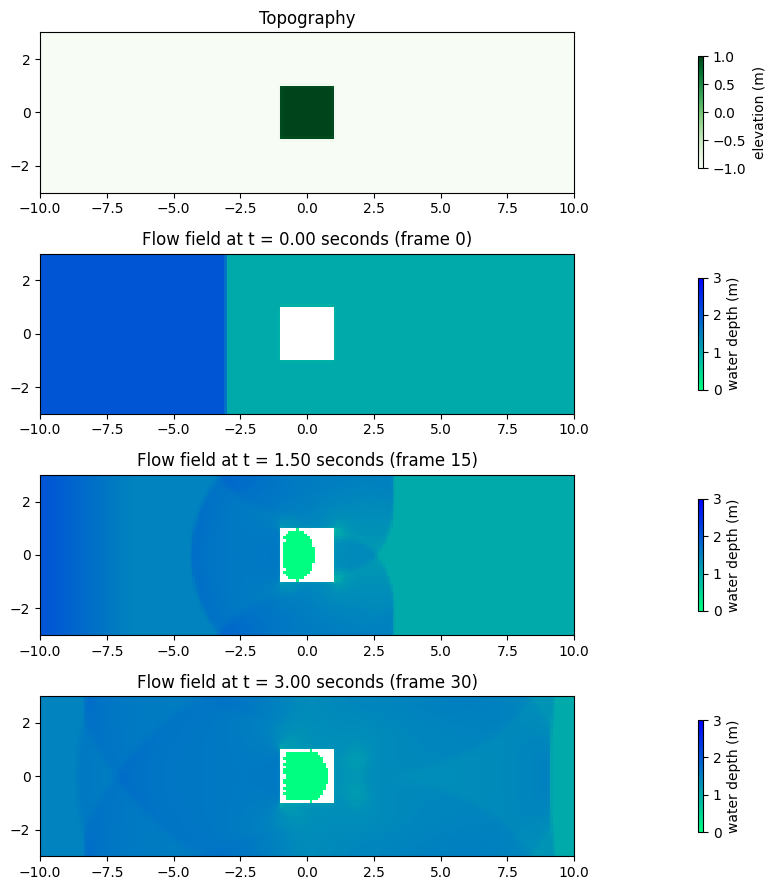

In [36]:
k = 15  # frame number for fgout frame to plot

framenos = [0, 15, 30]
fig,axs = subplots(len(framenos)+1,1,figsize=(9,3*len(framenos)))

p = axs[0].pcolormesh(X,Y,B[:,:,0],cmap='Greens')
colorbar(p, label='elevation (m)', shrink=0.7)
axs[0].axis('scaled')
axs[0].set_title('Topography')

for k,frameno in enumerate(framenos):
    depth_positive = depth_positive_fcn(X,Y,t[frameno])
    p = axs[k+1].pcolormesh(X,Y,depth_positive,cmap='winter_r')
    p.set_clim(0,3)
    colorbar(p, label='water depth (m)', shrink=0.7)
    axs[k+1].axis('scaled')
    axs[k+1].set_title(f'Flow field at t = {t[frameno]:.2f} seconds (frame {frameno})');

tight_layout();

## Function to make an animation of debris motion


In [37]:
def make_anim(debris_path_list, extent, figsize=(6,6), obst_list=[],
              domain=None, qoi_fcn=None, qoi_name='', cmap=None, climits=None):
    """
    :Inputs:
        - debris_path_list: a list of debris_tools.DebrisPath objects describing the path in time
            of each debris object.  This must first be computed and passed in.
        - extent: axis [x1,x2,y1,y2] for plots
        - figsize: figure size
        - obst_list: list of obstacles that were specified when computing the debris paths, a list
            of dictionaries (for adding the obstacles to the plots)
        - domain: the domain specified when computing the debris paths, a rectangle [x1,x2,y1,y2] bounded
            by solid walls the debris objects could not penetrate (for plotting these walls).
            domain == None is equivalent to domain == [-inf, inf, -inf, inf] (no walls on any side)
        - qoi_fcn: function of (x,y,t) specifying the flow quantity to plot with pcolormesh
        - cmap: colormap for qoi
        - climits: set limits for color scale so all frames have same limits
    """
    
    figs = [] # to accumulate frames of animation

    times = debris_path_list[0].times  # assume same times for each debris object
    
    for n,t_n in enumerate(times):
        
        fig = figure(figsize=figsize)

        # plot any obstacles:
        for obst in obst_list:
            shapely.plotting.plot_polygon(obst['polygon'], add_points=False,
                                          color='blue', alpha=0.0)

        if domain is not None:
            # plot any walls:
            x1,x2,y1,y2 = extent
            x1wall,x2wall,y1wall,y2wall = domain
            plot([x1wall,x1wall], [max(y1wall,y1),min(y2wall,y2)], 'g')
            plot([x2wall,x2wall], [max(y1wall,y1),min(y2wall,y2)], 'g')
            plot([max(x1wall,x1),min(x2wall,x2)], [y1wall,y1wall], 'g')
            plot([max(x1wall,x1),min(x2wall,x2)], [y2wall,y2wall], 'g')

        if qoi_fcn is not None:
            if cmap is None:
                cmap = 'Blues'
            qoi = qoi_fcn(X, Y, t_n)
            p = pcolormesh(X, Y, qoi, cmap=cmap)
            if climits is not None:
                p.set_clim(climits)
            colorbar(p, label=qoi_name, shrink=0.7)
            #print('plotting qoi not yet implemented')

        # plot debris paths:
        for debris_path in debris_path_list:
            debris = debris_path.debris
            #t_n = debris_path.times[n]
            z_n = debris_path.z_path[n]
            xc,yc = debris.get_corners(z_n, close_poly=True)
            plot(xc, yc, 'yellow')
            
        axis(extent)
        title(f'Time {t_n:.2f} seconds')
        gca().set_aspect(1)
        figs.append(fig)
        close(fig)

    images = animation_tools.make_images(figs)
    anim = animation_tools.animate_images(images, figsize=figsize)
    return anim

## Debris objects in flow

This cell may take a while to run if there are more than 1 or 2 debris objects...

z0=(-4,-1): h_actual=2.000, h_tracker=2.000
z0=(-3,-2): h_actual=1.333, h_tracker=1.333
z0=(-3,0): h_actual=1.333, h_tracker=1.333
z0=(-2,-2): h_actual=1.000, h_tracker=1.000
z0=(-2,0): h_actual=1.000, h_tracker=1.000


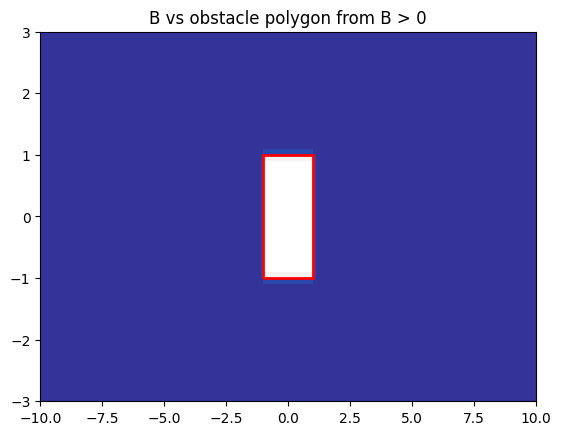

In [38]:
debris_list = []

if 1:
    # single obstacle
    debris = debris_tracking.DebrisObject()
    debris.L = [0.5,1.5,0.5]
    debris.phi = [pi/2, pi/2, pi/2]
    debris.z = (-4, -1, 0)
    debris.advect = True  # Particle advected with flow
    debris_list.append(debris)

if 1:
    for xd in [-3, -2]:
        for yd in [-2,0]:
            debris = debris_tracking.DebrisObject()
            debris.L = [0.5,1.5,0.5]
            debris.phi = [pi/2, pi/2, pi/2]
            debris.z = (xd, yd, 0)
            debris.advect = True  # Particle advected with flow
            debris_list.append(debris)


z0_list = [db.z for db in debris_list]
h = lambda x,y,t: depth_fcn(x,y,t) #in this case doesn't do anything since there's no grounding, but if there is in a future test case this will keep the sim realistic allowing grounding
for z in z0_list:
    x0, y0, th = z
    print(f"z0=({x0},{y0}): h_actual={depth_fcn(x0,y0,0):.3f}, h_tracker={h(x0,y0,0):.3f}") # checking all good

# obstacles:
cells = []
for i in range(mask.shape[0]):
    for j in range(mask.shape[1]):
        if mask[i,j]:
            xc,yc = X[i,j], Y[i,j]
            cells.append(shapely.geometry.box(xc-dx/2,yc-dy/2,xc+dx/2,yc+dy/2))

obst_polygon = shapely.unary_union(cells)
obst = debris_tracking.make_rectangular_obstacle(obst_polygon.bounds[0],obst_polygon.bounds[2],obst_polygon.bounds[1],obst_polygon.bounds[3])
obst_list = [obst]
fig, ax = subplots()
ax.pcolormesh(X, Y, B_xy, cmap='terrain')
shapely.plotting.plot_polygon(obst['polygon'], ax=ax,
                              add_points=False, facecolor='none',
                              edgecolor='red', linewidth=2)
ax.set_title('B vs obstacle polygon from B > 0') # checking overlap


if 1:
    ywall = 3
    domain = [x.min(), x.max(), -ywall, ywall] # prevent out of bounds in x direction
else:
    domain = None

t0 = 0.
nsteps = 100 # to account for smaller dt
dt = 0.1 # same as fgout timesteps, prevents situations where debris seemingly teleports inside an obstacle, then has to be remapped to a different location then it would've been if it collided naturally with the flow

debris_path_list = debris_tracking.make_debris_path_list(
    debris_list, z0_list, obst_list, domain,
    t0, dt, nsteps, h, u_fcn, v_fcn)


## Make an animation

If you want to play around with the plotting, color maps, etc, you can change the definition of `make_anim` above and then re-execute the cell below without recomputing `debris_path_list`.

In [39]:
from clawpack.visclaw import colormaps
#cmap = 'winter_r'
cmap = colormaps.make_colormap({0:[0,1,1], 1:[0,0,1]})

In [40]:
# make animation:

anim = make_anim(debris_path_list, extent=[-10,10,-3.2,3.2], figsize=(9,4), 
                 obst_list=obst_list, domain=domain,
                 qoi_fcn=depth_positive_fcn, qoi_name='water depth (m)',
                 cmap=cmap, climits=(0,3))
HTML(anim.to_jshtml())